In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("working_datasets/cleaned_enrolment_data.csv")

In [3]:
df

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,enrolment_month
0,2025-03-02,Meghalaya,East_Khasi_Hills,793121,11,61,37,2025-03
1,2025-03-09,Bihar,Muzaffarpur,843331,20,49,12,2025-03
2,2025-03-09,Bihar,Bhagalpur,812005,13,40,18,2025-03
3,2025-03-09,Bihar,Darbhanga,847108,18,120,22,2025-03
4,2025-03-09,Bihar,West_Champaran,845418,30,48,10,2025-03
...,...,...,...,...,...,...,...,...
983046,2025-12-31,West_Bengal,Hooghly,712704,0,1,0,2025-12
983047,2025-12-31,West_Bengal,Kolkata,700066,1,14,0,2025-12
983048,2025-12-31,West_Bengal,Kolkata,700066,0,1,0,2025-12
983049,2025-12-31,West_Bengal,West_Midnapore,721161,2,0,0,2025-12


In [4]:
# total distinct months from previous analysis: 9

In [7]:
# taking the monthly summation of enrolments per states
monthly_enrolments = df.groupby(['enrolment_month', 'state'])[['age_0_5', 'age_5_17', 'age_18_greater']].sum().reset_index()
monthly_enrolments


,enrolment_month,state,age_0_5,age_5_17,age_18_greater
0,2025-03,Andhra_Pradesh,43,44,29
1,2025-03,Assam,587,1105,800
2,2025-03,Bihar,516,1392,444
3,2025-03,Chhattisgarh,115,46,99
4,2025-03,Delhi,181,102,85
...,...,...,...,...,...
269,2025-12,Telangana,13448,2222,139
270,2025-12,Tripura,1483,576,18
271,2025-12,Uttar_Pradesh,66126,46876,1402
272,2025-12,Uttarakhand,5174,649,41


In [8]:
# taking a summation of the total enrolments for these intateks in the uniqe months
monthly_enrolments['total_monthly_enrolments'] = (
    monthly_enrolments['age_0_5'] +
    monthly_enrolments['age_5_17'] +
    monthly_enrolments['age_18_greater']
)

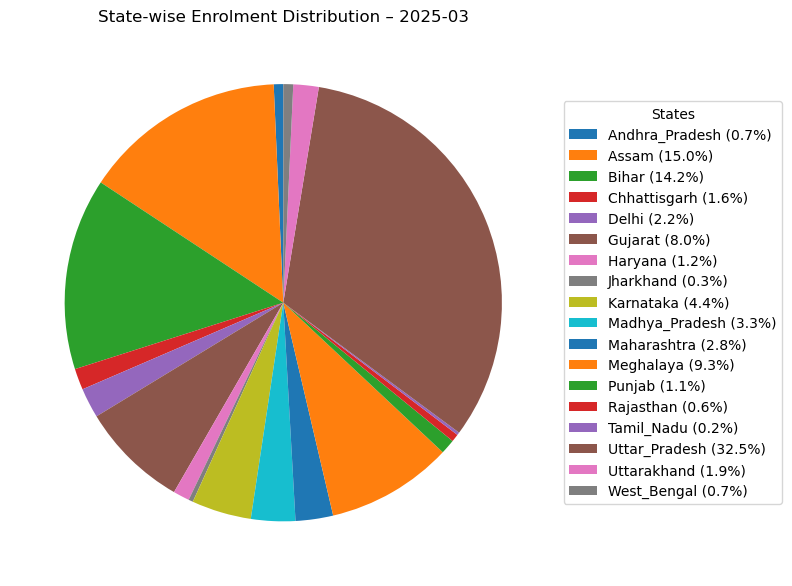

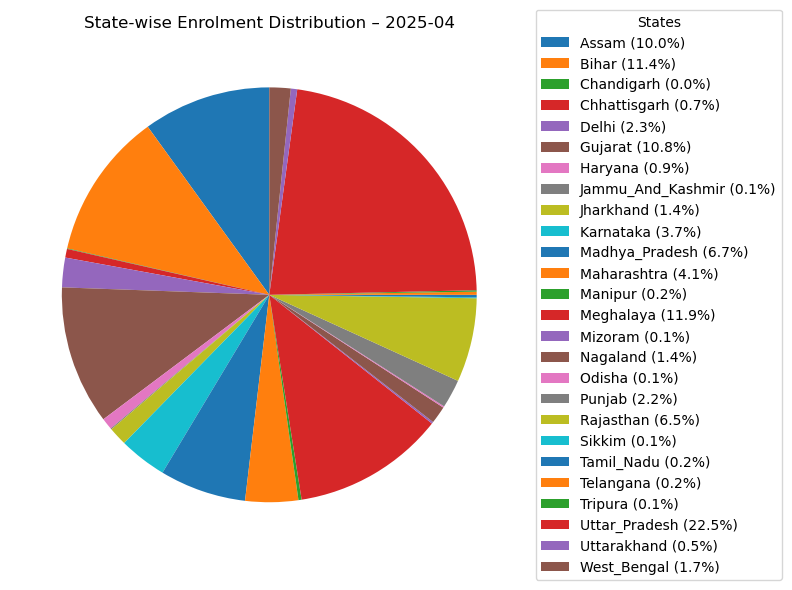

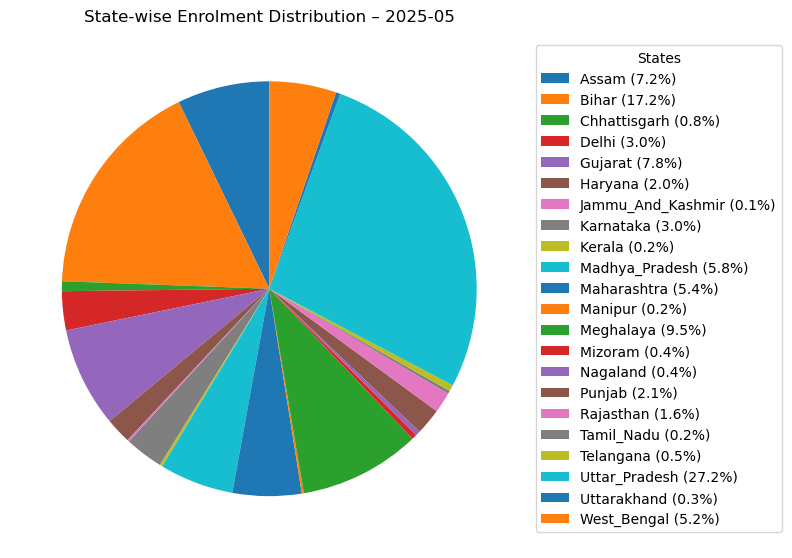

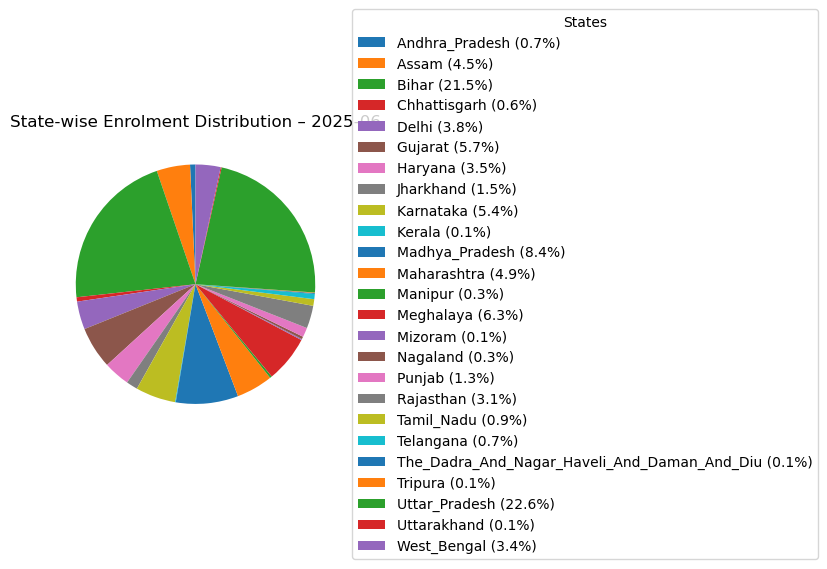

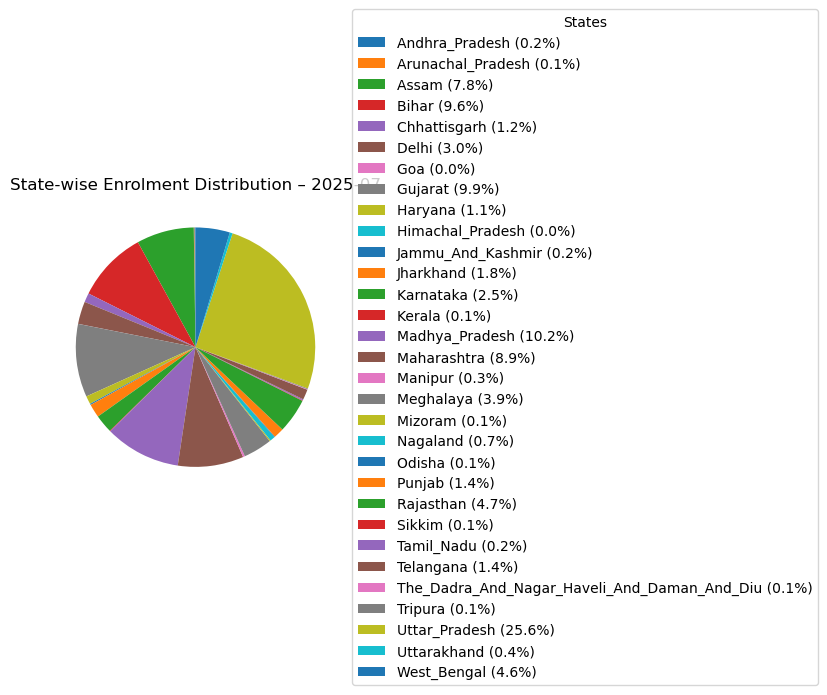

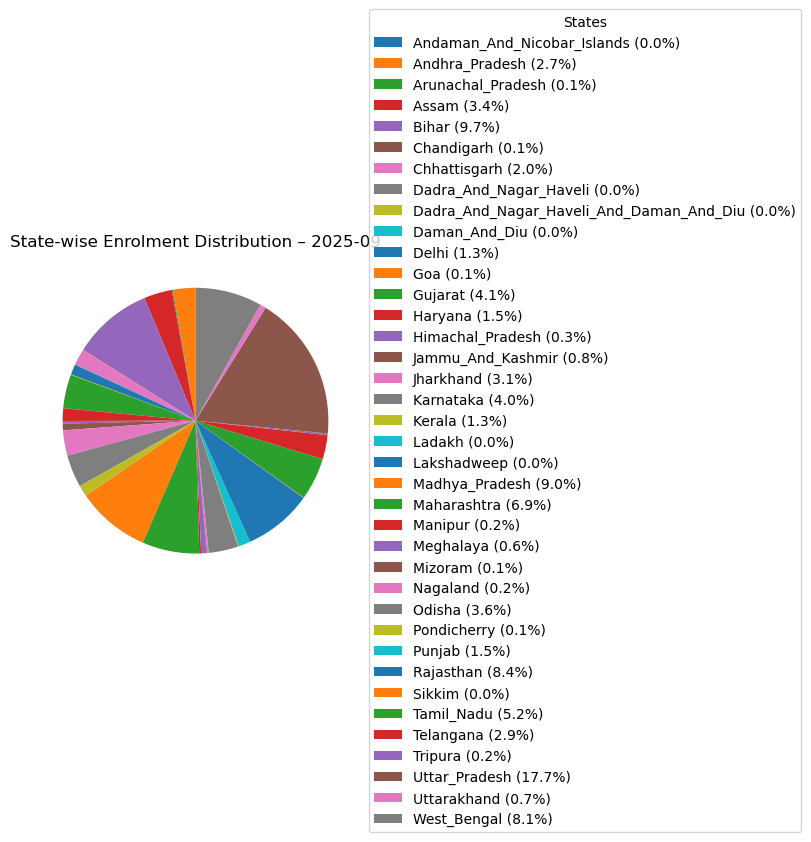

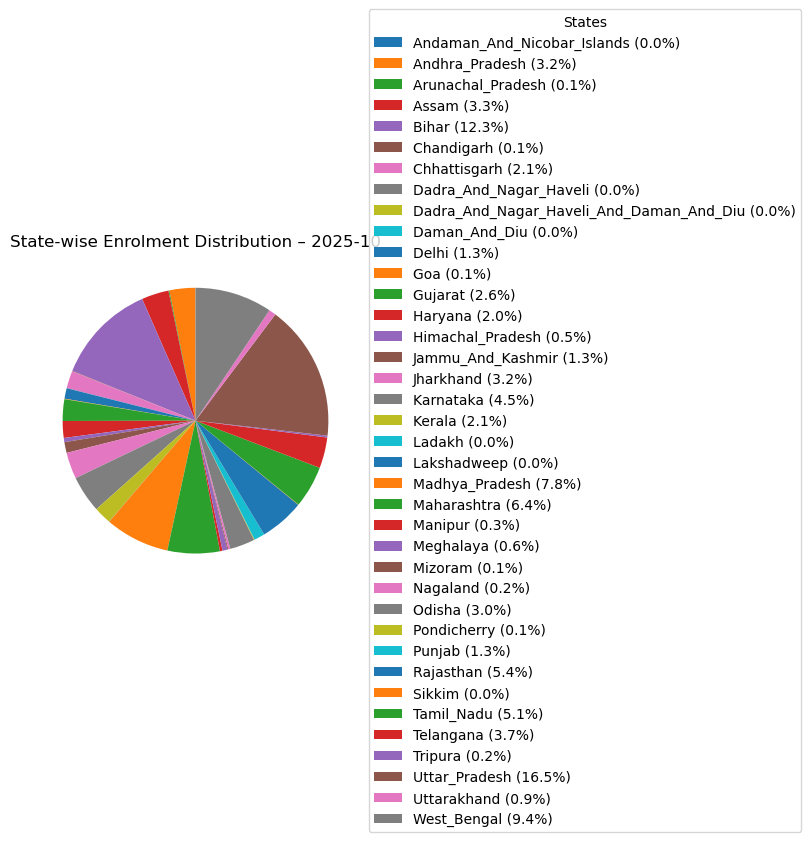

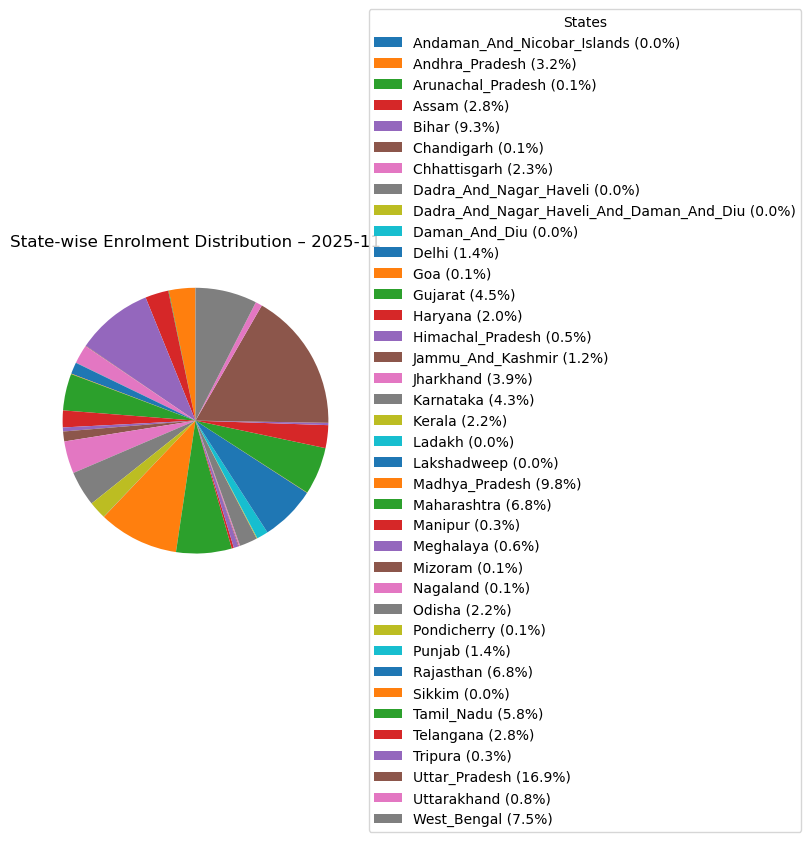

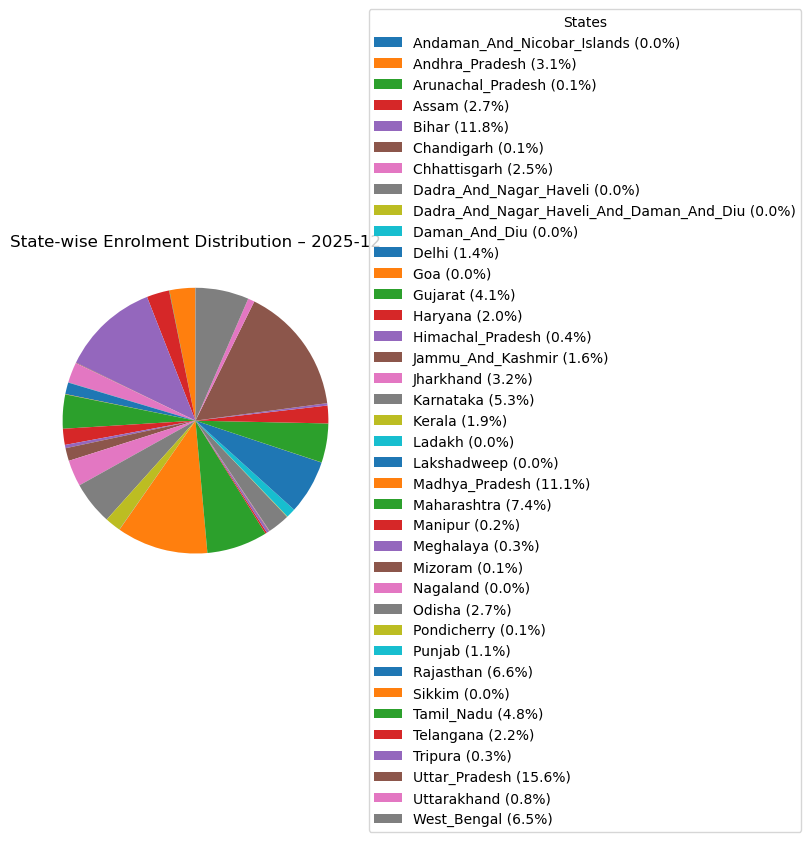

In [12]:
months = sorted(monthly_enrolments['enrolment_month'].unique())
i = 0

for month in months:
    month_data = monthly_enrolments[
        monthly_enrolments['enrolment_month'] == month
    ]

    values = month_data['total_monthly_enrolments']
    states = month_data['state']

    # Build legend labels with percentages
    total = values.sum()
    legend_labels = [
        f"{state} ({val/total*100:.1f}%)"
        for state, val in zip(states, values)
    ]

    fig, ax = plt.subplots(figsize=(8, 8))

    ax.pie(
        values,
        startangle=90
    )

    ax.set_title(f'State-wise Enrolment Distribution – {month}')

    # Legend OUTSIDE the pie
    ax.legend(
        legend_labels,
        title="States",
        loc="center left",
        bbox_to_anchor=(1, 0.5)
    )

    plt.tight_layout()
    plt.savefig(
        f'enrol_graphs/enrolment_per_state_per_month_{i}.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()
    plt.close()

    i += 1

In [13]:
from PIL import Image
import os

imgs = sorted([f for f in os.listdir('enrol_graphs') if f.endswith('.png')])
images = [Image.open(f'enrol_graphs/{img}') for img in imgs]

w, h = images[0].size
rows, cols = 3, 3

combined = Image.new('RGB', (cols * w, rows * h), (255, 255, 255))

for i, img in enumerate(images):
    combined.paste(img, ((i % cols) * w, (i // cols) * h))

combined.save('graphs/all_months_enrolment_distribution.png', dpi=(300, 300))

In [14]:
df_enrol = df

In [16]:
df_bio = pd.read_csv("working_datasets/cleaned_biometrics_data.csv")
df_demo = pd.read_csv("working_datasets/cleaned_demographics_data.csv")